In [43]:
# load library
library(WGCNA)
library(edgeR)
library(variancePartition)

In [44]:
removing_species_notation = function(data){
    names_sncRNA = gsub("hsa-","",colnames(data))
    names_sncRNA = gsub("Homo_sapiens_","",names_sncRNA)
    colnames(data) = names_sncRNA
    return(data)
}

In [45]:
# load data
path = "analysis_manuscript_DREAM_WGCNA/self_contained_analysis/data"
df_dynamic = readRDS(paste(path,"/df_dynamic_DC.RDS",sep=""))

miRNA_DGE = readRDS(paste(path,"/DGEList_miRNA_filtered_norm.RDS",sep=""))
piRNA_DGE = readRDS(paste(path,"/DGEList_piRNA_filtered_norm.RDS",sep=""))
tRNA_DGE  = readRDS(paste(path,"/DGEList_tRNA_filtered_norm.RDS",sep=""))

dynamic_candidates  = readRDS(paste(path,"/dynamic_cadidate_all_subjects_DC_DE.RDS",sep=""))

info = read.csv(paste(path,"/data_for_modeling.csv",sep=""),
                row.names = read.csv(paste(path,"/data_for_modeling.csv",sep=""))[,1])[,-1]

In [46]:
grep("107",colnames(miRNA_DGE))

[1] 159 160 161 162 163 164

In [47]:
# get the dynamic sncRNA set after following Morgan's pipeline
dynamic_miRNA = dynamic_candidates$miRNA_DE[(dynamic_candidates$miRNA_DE$dynamic_count_DE >= 7),]$miRNA
dynamic_piRNA = dynamic_candidates$piRNA_DE[(dynamic_candidates$piRNA_DE$dynamic_count_DE >= 7),]$piRNA
dynamic_tRNA = dynamic_candidates$tRNA_DE[(dynamic_candidates$tRNA_DE$dynamic_count_DE >= 7),]$tRNA

sncRNA_DGE = rbind(miRNA_DGE[dynamic_miRNA,rownames(info)],
                   piRNA_DGE[dynamic_piRNA,rownames(info)],
                   tRNA_DGE[dynamic_tRNA,rownames(info)])

In [48]:
# get the dynamic PSS reference visits
increase_dynamic = read.csv(paste(path,"/mark_increase_dynamic.csv",sep=""))[,-1]
stability_low_dynamic = read.csv(paste(path,"/mark_stability_low_dynamic.csv",sep=""))[,-1]
stability_moderate_dynamic = read.csv(paste(path,"/mark_stability_moderate_dynamic.csv",sep=""))[,-1]

# function to get samples from PSS dynamic classification data.frame  
get_samples <- function(mark_df, delay = 0){
    subjects = gsub("50","",mark_df$Record_ID) # remove "50", from the Record_ID
    visit = mark_df$mark+delay
    sample = paste(subjects,"-",visit,sep="") # putting subject and visit together
    return(sample)
}
# identify samples 2 visits after the dynamic
increase_dynamic_2m   = get_samples(increase_dynamic,delay=2)
stable_low_dynamic_2m = get_samples(stability_low_dynamic,delay=2)
stable_mod_dynamic_2m = get_samples(stability_moderate_dynamic,delay=2)

In [49]:
nrow(stability_moderate_dynamic)

[1] 25

In [50]:
length(unique(increase_dynamic$Record_ID))
length(unique(stability_low_dynamic$Record_ID))
length(unique(stability_moderate_dynamic$Record_ID))

[1] 10

[1] 10

[1] 13

In [51]:
# setting variable type
info$Batch   = as.factor(info$Batch) 
info$Subject = as.factor(info$Subject) 

In [52]:
# selecting samples

# all dynamics
info_all = info[c(increase_dynamic_2m,
                  stable_low_dynamic_2m,
                  stable_mod_dynamic_2m),]
info_all$dynamic  = c(rep("increase",length(increase_dynamic_2m)),
                      rep("stable_low",length(stable_low_dynamic_2m)),
                      rep("stable_mod",length(stable_mod_dynamic_2m)))
info_all$dynamic = as.factor(info_all$dynamic)

# set1: stable low 
info_low = info[c(stable_low_dynamic_2m),]

# set2:  stable moderate
info_mod = info[c(stable_mod_dynamic_2m),]

# set3: increase
info_incres = info[c(increase_dynamic_2m),]

In [53]:
length(increase_dynamic_2m)

[1] 10

In [54]:
length(stable_mod_dynamic_2m)

[1] 25

In [55]:
# get voom processed data!
design_matrix_null = ~  (1|Batch) + (1|Subject)
design_matrix = ~ ACE*PSS_2m_prior + (1|Batch) + (1|Subject)
design_matrix2 = ~ ACE*PSS_2m_prior + (1|Batch) 

# identifying samples with PSS avaiable two months before!
complete_PSS_2m_samples= rownames(na.omit(info[,c("Sample","PSS_2m_prior")]))

voom_expr_unf = voomWithDreamWeights(counts = sncRNA_DGE[,complete_PSS_2m_samples], 
                                    formula = design_matrix, 
                                    data = info[complete_PSS_2m_samples,], 
                                    lib.size = info[complete_PSS_2m_samples,]$sequence_count)

voom_expr_all = voomWithDreamWeights(counts = sncRNA_DGE[,info_all$Sample], 
                                     formula = design_matrix, 
                                     data = info_all, 
                                     lib.size = info_all$sequence_count)

voom_expr_set1 = voomWithDreamWeights(counts = sncRNA_DGE[,info_low$Sample], 
                                      formula = design_matrix, 
                                      data = info_low, 
                                      lib.size = info_low$sequence_count)

voom_expr_set2 = voomWithDreamWeights(counts = sncRNA_DGE[,info_mod$Sample], 
                                      formula = design_matrix, 
                                      data = info_mod, 
                                      lib.size = info_mod$sequence_count)
voom_expr_set3 = voomWithDreamWeights(counts = sncRNA_DGE[,info_incres$Sample], 
                                      formula = design_matrix2, 
                                      data = info_incres, 
                                      lib.size = info_incres$sequence_count)

Memory usage to store result: >2.4 Mb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >942.3 Kb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >482.1 Kb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >442.7 Kb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >263 Kb

Dividing work into 9 chunks...


Total:1 s



In [56]:
ACE_low = rownames(info[info$ACE<=1,])
ACE_high = rownames(info[info$ACE>1,])

In [57]:
voom_expr_ACE_low = voomWithDreamWeights(counts = sncRNA_DGE[,ACE_low], 
                                     formula = design_matrix_null, 
                                     data = info[ACE_low,], 
                                     lib.size = info[ACE_low,]$sequence_count)

voom_expr_ACE_high = voomWithDreamWeights(counts = sncRNA_DGE[,ACE_high], 
                                     formula = design_matrix_null, 
                                     data = info[ACE_high,], 
                                     lib.size = info[ACE_high,]$sequence_count)

Memory usage to store result: >1.4 Mb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >1.1 Mb

Dividing work into 9 chunks...


Total:2 s



### Reference WGCNA (low stable stress)

In [58]:
wgcna_low = t(voom_expr_set1$E) # stable low
wgcna_low = removing_species_notation(wgcna_low)
cat("Sample:",nrow(wgcna_low))

Sample: 28

In [59]:
wgcna_low = t(voom_expr_set1$E) # stable low
wgcna_low = removing_species_notation(wgcna_low)
cat("Sample:",nrow(wgcna_low))

Sample: 28

In [60]:
# Set of soft-thresholding power to check
powers = c(seq(4,10,by=1), seq(12,20, by=2));

powerTables = list(data = pickSoftThreshold(wgcna_low, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # select 9

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4    0.101 -0.199         0.9140   9.930     9.620  21.30
2      5    0.450 -0.492         0.8380   7.080     6.430  17.60
3      6    0.553 -0.736         0.7410   5.360     4.540  15.10
4      7    0.664 -0.800         0.8190   4.230     3.310  13.30
5      8    0.769 -0.873         0.8660   3.460     2.470  11.90
6      9    0.776 -0.914         0.8270   2.900     1.920  10.80
7     10    0.782 -0.967         0.7920   2.480     1.620   9.91
8     12    0.781 -1.030         0.7660   1.910     1.260   8.48
9     14    0.840 -1.050         0.8240   1.540     1.030   7.40
10    16    0.821 -1.080         0.8180   1.290     0.963   6.54
11    18    0.202 -2.450         0.0938   1.110     0.803   5.83
12    20    0.194 -2.290         0.0979   0.971     0.668   5.23


 Calculating module eigengenes block-wise from all genes


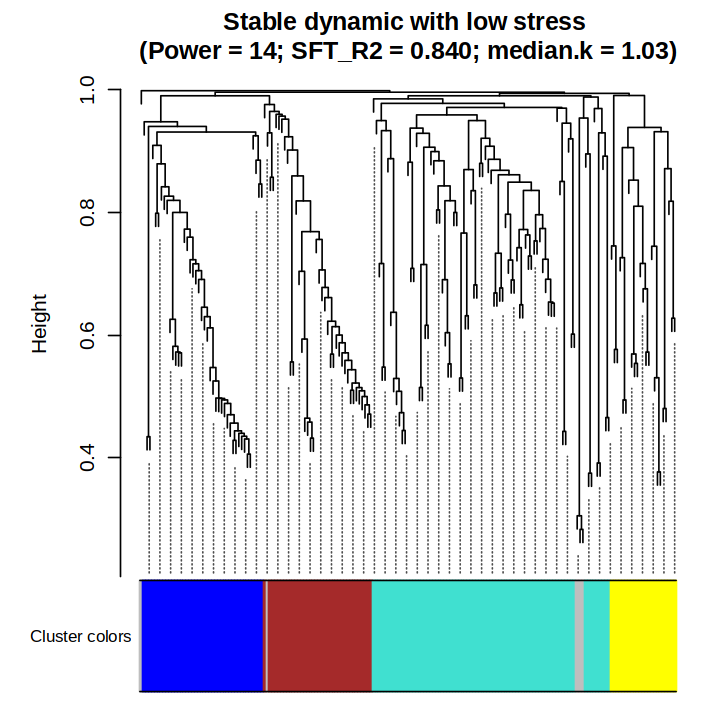

In [61]:
net = blockwiseModules(wgcna_low, power = 14, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19, # minModule = 10% of total
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)
# Convert labels to colors for plotting
reference_colors = labels2colors(net$colors)
names(reference_colors) = names(net$colors)
multiColor  = list(Set1 = reference_colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 6, repr.plot.height = 6)
plotDendroAndColors(net$dendrograms[[1]], reference_colors[net$blockGenes[[1]]],
                    main = "Stable dynamic with low stress \n(Power = 14; SFT_R2 = 0.840; median.k = 1.03)",
                    "Cluster colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)
# Calculate MEs with color labels
MEs0 = moduleEigengenes(wgcna_low, reference_colors)$eigengenes
MEs = orderMEs(MEs0)
# cluster membership
datKME=signedKME(wgcna_low, MEs, outputColumnName="MM_")
# Get cluster nodes
brown = names(reference_colors[reference_colors == "brown"])
blue = names(reference_colors[reference_colors == "blue"])
turquoise = names(reference_colors[reference_colors == "turquoise"])
yellow = names(reference_colors[reference_colors == "yellow"])

TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


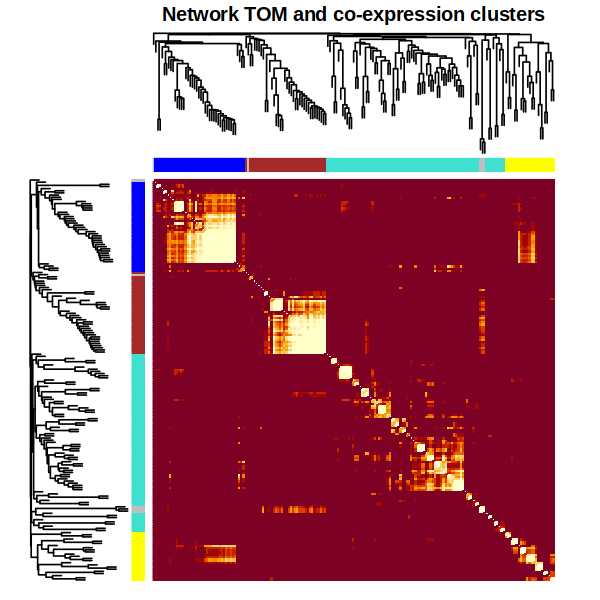

In [62]:
options(repr.plot.width = 5, repr.plot.height = 5)
diss1=1-TOMsimilarityFromExpr(wgcna_low, power =14)
diag(diss1) = NA

# svg(filename = "Plots/Network_TOM_visualization_1.svg",width = 6,height = 6)
#pdf(file = "reference_network_TOM.pdf",width = 5,height = 5)

a = TOMplot(diss1^14, net$dendrograms[[1]], reference_colors,
            main = "Network TOM and co-expression clusters")
#dev.off()

In [63]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [64]:
# looking at the top 20 highest cluster membership nodes (kME) within each cluster
cat("BLUE\n")
datKME %>% arrange(desc(MM_blue)) %>% rownames() %>% head(,n=20)

BLUE


[1] "piR-720500"  "piR-6305852" "piR-6738734" "piR-3004347" "piR-7025211"
 [6] "piR-2649712" "piR-3416180" "piR-2906214" "piR-357703"  "piR-765768" 
[11] "piR-776281"  "piR-4642665" "piR-2663764" "piR-775507"  "piR-4957227"
[16] "piR-7720620" "miR-1247-3p" "piR-2626556" "piR-2845812" "piR-6543910"

In [65]:
cat("BROWN\n")
datKME %>% arrange(desc(MM_brown)) %>% rownames() %>% head(,n=20) 

BROWN


[1] "miR-148a-3p" "piR-2866828" "miR-26b-5p"  "miR-200a-3p" "piR-148659" 
 [6] "piR-383453"  "piR-155056"  "miR-375-3p"  "miR-363-3p"  "miR-141-3p" 
[11] "piR-167717"  "miR-92a-3p"  "miR-429"     "miR-23b-3p"  "let-7a-5p"  
[16] "piR-168697"  "piR-187041"  "piR-170413"  "let-7c-5p"   "piR-137463"

In [66]:
cat("TURQUOISE\n")
datKME %>% arrange(desc(MM_turquoise)) %>% rownames() %>% head(,n=20)

TURQUOISE


[1] "miR-7977"    "piR-2951599" "piR-2826329" "piR-2866342" "miR-6765-3p"
 [6] "piR-2648677" "piR-707596"  "piR-355426"  "piR-1248184" "piR-1800335"
[11] "miR-3182"    "miR-4454"    "piR-367314"  "miR-12136"   "piR-3493222"
[16] "piR-3169149" "piR-173953"  "piR-2717221" "piR-2742625" "piR-2831963"

In [67]:
cat("YELLOW\n")
datKME %>% arrange(desc(MM_yellow)) %>% rownames() %>% head(,n=20)

YELLOW


[1] "piR-12830"   "piR-2996788" "piR-7126455" "piR-2866894" "miR-449a"   
 [6] "miR-34c-5p"  "piR-1234402" "piR-769499"  "piR-17"      "piR-18"     
[11] "piR-270995"  "miR-4497"    "piR-55506"   "piR-300977"  "piR-108039" 
[16] "miR-891a-5p" "piR-6475875" "piR-5955057" "piR-163216"  "piR-434774"

In [68]:
print_prop = function(set){
    cat("Total size:",length(set),"\n")
    cat("miRNA: ",paste(length(grep("miR|let",set)),
               " (",length(grep("miR|let",set))/length(set),sep=""),")\n",sep="")
    cat("piRNA: ",paste(length(grep("piR",set)),
               " (",length(grep("piR",set))/length(set),sep=""),")\n",sep="")
    cat("tRNA: ",paste(length(grep("tR",set)),
               " (",length(grep("tR",set))/length(set),sep=""),")\n",sep="")
}

In [69]:
print_prop(yellow)

Total size: 23 
miRNA: 4 (0.173913043478261)
piRNA: 19 (0.826086956521739)
tRNA: 0 (0)


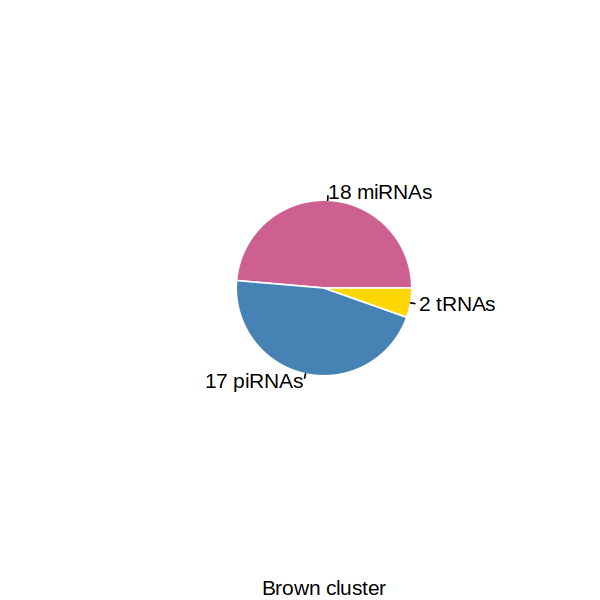

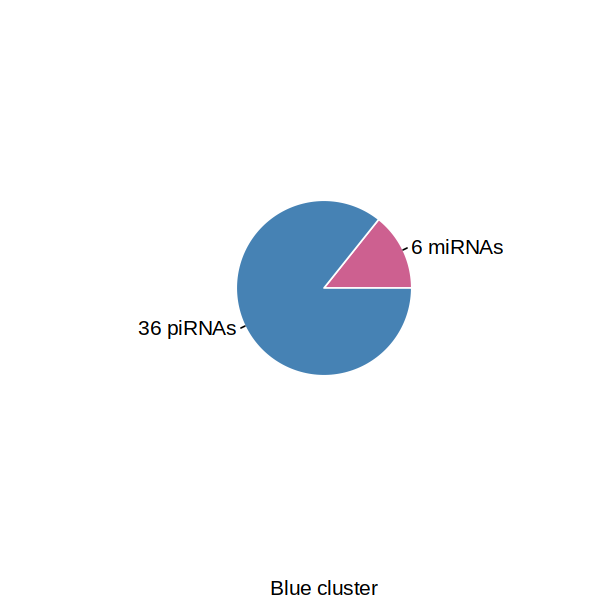

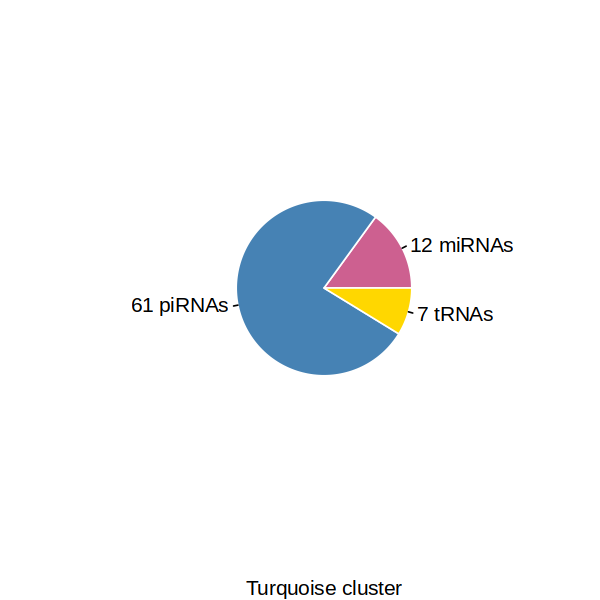

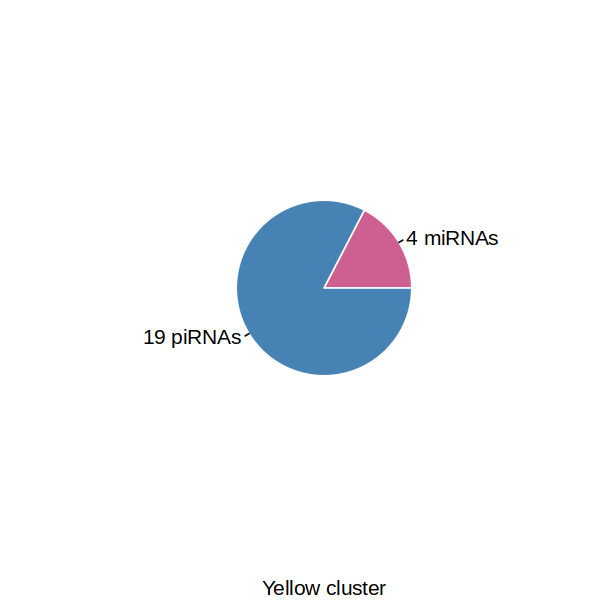

In [70]:
options(repr.plot.width = 5, repr.plot.height = 5)
# pdf(file = "ref_brow_cluster_composition.pdf",width = 5,height = 5)
pie(c(18,17,2),labels =  c("18 miRNAs","17 piRNAs","2 tRNAs"),
    radius = 0.5, sub = "Brown cluster",
    border = "white", col=c('hotpink3','steelblue','gold'))
# dev.off()
# pdf(file = "ref_blue_cluster_composition.pdf",width = 5,height = 5)
pie(c(6,36),labels =  c("6 miRNAs","36 piRNAs"),
    radius = 0.5, sub = "Blue cluster",
    border = "white", col=c('hotpink3','steelblue'))
# dev.off()
# pdf(file = "ref_turquoise_cluster_composition.pdf",width = 5,height = 5)
pie(c(12,61,7),labels =  c("12 miRNAs","61 piRNAs","7 tRNAs"),
    radius = 0.5, sub = "Turquoise cluster",
    border = "white", col=c('hotpink3','steelblue','gold'))
# dev.off()
# pdf(file = "ref_yellow_cluster_composition.pdf",width = 5,height = 5)
pie(c(4,19),labels =  c("4 miRNAs","19 piRNAs"),
    radius = 0.5, sub = "Yellow cluster",
    border = "white", col=c('hotpink3','steelblue'))
# dev.off()

Unfiltered WGCNA co-expression cluster

In [71]:
wgcna_unf = t(voom_expr_unf$E) 
wgcna_unf = removing_species_notation(wgcna_unf)
cat("Sample:",nrow(wgcna_unf),"\n")

# Set of soft-thresholding power to check
powers = c(seq(4,10,by=1), seq(12,20, by=2));

powerTables = list(data = pickSoftThreshold(wgcna_unf, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # select 9

Sample: 175 
   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4   0.5760 -0.461         0.6240   10.60     9.340  26.70
2      5   0.7750 -0.640         0.8030    7.69     6.510  21.90
3      6   0.8150 -0.752         0.8290    5.93     4.730  18.60
4      7   0.7320 -0.829         0.6950    4.76     3.400  16.30
5      8   0.1430 -2.360        -0.0789    3.94     2.650  14.60
6      9   0.1530 -2.390        -0.0625    3.34     2.270  13.30
7     10   0.1680 -2.520        -0.0455    2.89     1.870  12.20
8     12   0.1340 -2.170        -0.1120    2.25     1.340  10.60
9     14   0.1410 -2.120        -0.1040    1.84     1.130   9.48
10    16   0.1150 -1.880        -0.1110    1.55     1.010   8.59
11    18   0.1150 -1.890        -0.1030    1.34     0.927   7.85
12    20   0.0964 -2.200        -0.0548    1.18     0.835   7.24


 Calculating module eigengenes block-wise from all genes


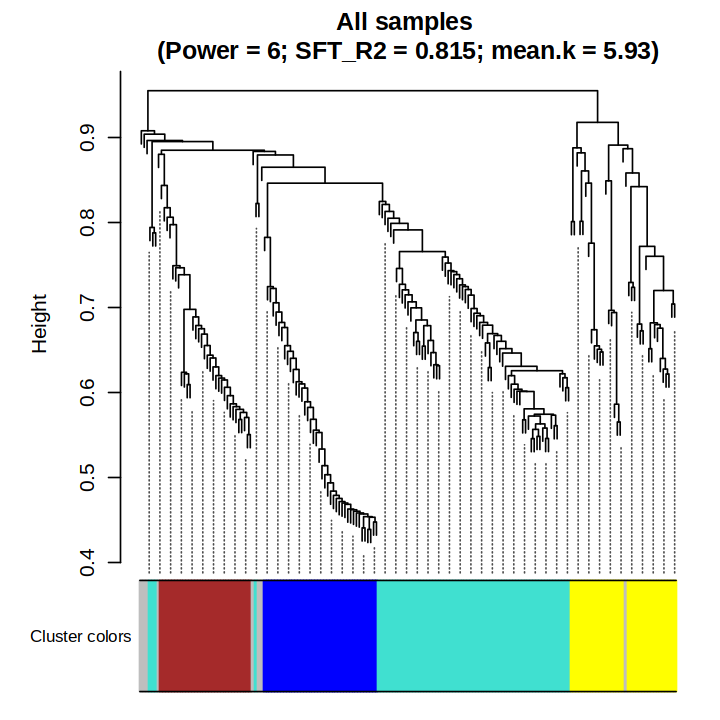

In [91]:
net = blockwiseModules(wgcna_unf, power = 6, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19, # minModule = 10% of total
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)
# Convert labels to colors for plotting
reference_colors = labels2colors(net$colors)
names(reference_colors) = names(net$colors)
to_brown  = which(reference_colors == "yellow")
to_yellow = which(reference_colors == "brown")
reference_colors[to_brown] = "brown"
reference_colors[to_yellow] = "yellow"

#multiColor  = list(Set1 = reference_colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 6, repr.plot.height = 6)
plotDendroAndColors(net$dendrograms[[1]], reference_colors[net$blockGenes[[1]]],
                    main = "All samples \n(Power = 6; SFT_R2 = 0.815; mean.k = 5.93)",
                    "Cluster colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)
# Calculate MEs with color labels
MEs0 = moduleEigengenes(wgcna_unf, reference_colors)$eigengenes
MEs = orderMEs(MEs0)
# cluster membership
datKME=signedKME(wgcna_unf, MEs, outputColumnName="MM_")
# Get cluster nodes
brown_1 = names(reference_colors[reference_colors == "brown"])
blue_1 = names(reference_colors[reference_colors == "blue"])
turquoise_1 = names(reference_colors[reference_colors == "turquoise"])
yellow_1 = names(reference_colors[reference_colors == "yellow"])

In [95]:
length(brown_1)

[1] 32

In [97]:
length(yellow_1)

[1] 36

In [109]:
grep("26b",brown)

[1] 11

In [ ]:
yellow
brown
turquoise
blue

In [134]:
grep("piR-762058",yellow)
grep("miR-449a",yellow)
grep("miR-26b-5p",brown)
grep("piR-77976",brown)
grep("piR-155056",brown)

[1] 21

[1] 1

[1] 11

[1] 20

[1] 26

In [ ]:
grep("piR-762058",yellow)

In [ ]:
miR-6765-3p

In [133]:
#grep("piR-762058",yellow)





[1] 1

In [105]:
datKME %>% arrange(desc(MM_yellow)) %>% rownames() %>% head(,n=20)

[1] "piR-7126455" "piR-2996788" "piR-12830"   "miR-449a"    "miR-34c-5p" 
 [6] "piR-2866894" "piR-270995"  "piR-18"      "piR-300977"  "piR-17"     
[11] "piR-108039"  "piR-153778"  "miR-4497"    "piR-1234402" "piR-769499" 
[16] "piR-409802"  "piR-193876"  "piR-6475875" "piR-5955057" "miR-6751-3p"

In [73]:
overlap_coef <- function(set1,set2){
    a = length(set1)
    b = length(set2)
    inter_ab = length(intersect(set1,set2))
    return(inter_ab/min(a,b))
}

mean(overlap_coef(brown,brown_1),
overlap_coef(blue,blue_1),
overlap_coef(turquoise,turquoise_1),
overlap_coef(yellow,yellow_1))

[1] 0.96875

In [74]:
overlap_coef(brown,brown_1)
overlap_coef(blue,blue_1)
overlap_coef(turquoise,turquoise_1)
overlap_coef(yellow,yellow_1)

[1] 0.96875

[1] 0.95

[1] 0.8732394

[1] 0.7391304

### WGCNA reference for ACE

In [75]:
# wgcna_ACE_low = t(voom_expr_ACE_low$E)
# wgcna_ACE_low = removing_species_notation(wgcna_ACE_low)

# wgcna_ACE_high = t(voom_expr_ACE_high$E)
# wgcna_ACE_high = removing_species_notation(wgcna_ACE_high) 

# cat("Sample:",nrow(wgcna_ACE_low),"\n")
# cat("Sample:",nrow(wgcna_ACE_high))

In [76]:
# # Set of soft-thresholding power to check
# powers = c(seq(4,20,by=1));

# powerTables = list(data = pickSoftThreshold(wgcna_ACE_low, powerVector=powers,verbose = F)[[2]]);
# collectGarbage(); # select 9

In [77]:
# net = blockwiseModules(wgcna_ACE_low, power = 5, networkType = "signed",
#                         TOMType = "signed", minModuleSize = 19, # minModule = 10% of total
#                         reassignThreshold = 0, mergeCutHeight = 0.25,
#                         numericLabels = TRUE, pamRespectsDendro = FALSE,
#                         verbose = 1)
# # Convert labels to colors for plotting
# reference_colors = labels2colors(net$colors)
# names(reference_colors) = names(net$colors)
# multiColor  = list(Set1 = reference_colors)
# # Plot the dendrogram and the module colors underneath
# options(repr.plot.width = 6, repr.plot.height = 6)
# plotDendroAndColors(net$dendrograms[[1]], reference_colors[net$blockGenes[[1]]],
#                     main = "ACE high \n(Power = 5; SFT_R2 = 0.462; median.k = 6.85)",
#                     "Cluster colors",
#                     dendroLabels = FALSE, hang = 0.03,
#                     addGuide = TRUE, guideHang = 0.05)
# # Calculate MEs with color labels
# MEs0 = moduleEigengenes(wgcna_low, reference_colors)$eigengenes
# MEs = orderMEs(MEs0)
# # cluster membership
# datKME=signedKME(wgcna_low, MEs, outputColumnName="MM_")
# # Get cluster nodes
# brown = names(reference_colors[reference_colors == "brown"])
# blue = names(reference_colors[reference_colors == "blue"])
# turquoise = names(reference_colors[reference_colors == "turquoise"])
# yellow = names(reference_colors[reference_colors == "yellow"])

### Preservation analysis

In [78]:
removing_species_notation = function(data){
    names_sncRNA = gsub("hsa-","",colnames(data))
    names_sncRNA = gsub("Homo_sapiens_","",names_sncRNA)
    colnames(data) = names_sncRNA
    return(data)
}

In [80]:
#ACE_multidata = multiData(Set1 = wgcna_ACE_low, Set2 = wgcna_ACE_high)

In [81]:
wgcna_all = t(voom_expr_all$E)
wgcna_all = removing_species_notation(wgcna_all)

wgcna_mod = t(voom_expr_set2$E) # stable moderate
wgcna_mod = removing_species_notation(wgcna_mod)

wgcna_inc = t(voom_expr_set3$E) # increase
wgcna_inc = removing_species_notation(wgcna_inc)

In [82]:
stable_multidata   = multiData(Set1 = wgcna_low, Set2 = wgcna_mod)
increase_multidata = multiData(Set1 = wgcna_low, Set2 = wgcna_inc)



In [ ]:
# preservation_in_ACE =   modulePreservation(ACE_multidata, 
#                                               multiColor = multiColor, 
#                                               dataIsExpr = TRUE,
#                                               networkType = "signed", 
#                                               referenceNetworks = 1)

In [83]:
preservation_in_stable =   modulePreservation(stable_multidata, 
                                              multiColor = multiColor, 
                                              dataIsExpr = TRUE,
                                              nPermutations = 100,
                                              networkType = "signed", 
                                              referenceNetworks = 1)

  ..checking data for excessive amounts of missing data..
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set


In [84]:
preservation_in_increase =   modulePreservation(increase_multidata, 
                                                multiColor = multiColor, 
                                                dataIsExpr = TRUE,
                                                nPermutations = 100,
                                                networkType = "signed", 
                                                referenceNetworks = 1)

  ..checking data for excessive amounts of missing data..
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set


In [85]:
result_stable   = preservation_in_stable$preservation$Z$ref.Set1$inColumnsAlsoPresentIn.Set2[,c(2:4)]
result_stable = result_stable[-which(rownames(result_stable) %in% c("gold","grey")),]
colnames(result_stable) = c("Z-Summary","Z-Density","Z-Connectivity")
result_stable$module = rownames(result_stable)
result_stable_melted = reshape2::melt(result_stable, id.vars = "module")

In [86]:
result_increase = preservation_in_increase$preservation$Z$ref.Set1$inColumnsAlsoPresentIn.Set2[,c(2:4)]
result_increase = result_increase[-which(rownames(result_increase) %in% c("gold","grey")),]
colnames(result_increase) = c("Z-Summary","Z-Density","Z-Connectivity")
result_increase$module = rownames(result_increase)
result_increase_melted = reshape2::melt(result_increase, id.vars = "module")

In [87]:
result_melted = rbind(result_stable_melted,result_increase_melted)

In [88]:
result_melted$comparison = c(rep("Compared to stable moderate-stress",nrow(result_stable_melted)),
                             rep("Compared to increased-stress",nrow(result_increase_melted)))

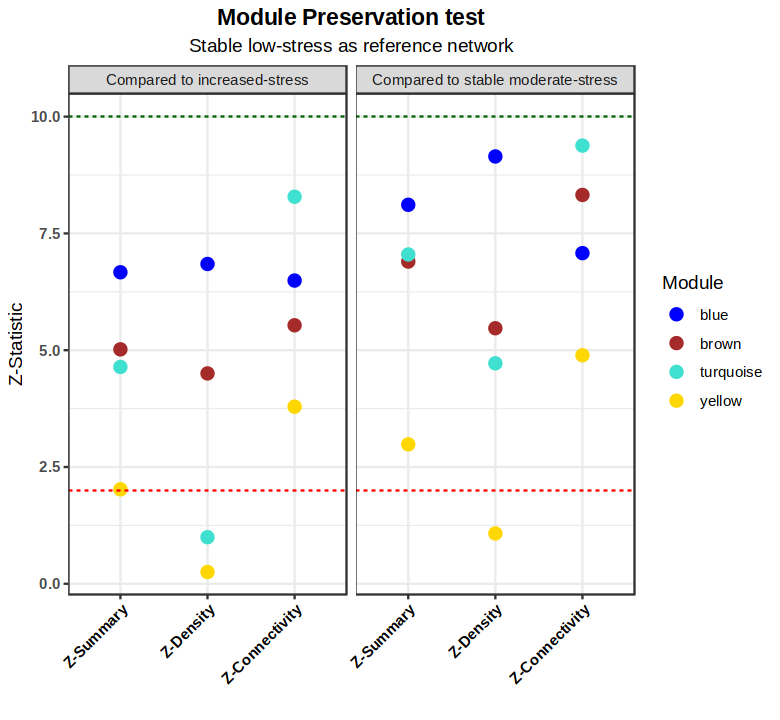

In [110]:
library(ggplot2)
options(repr.plot.width = 6.5, repr.plot.height = 6)

# pdf(file = "module_preservation_test.pdf",width = 6.5,height = 6)

ggplot(result_melted, aes(x = variable, y = value, color = module)) +
  geom_point(size = 3) +
  geom_hline(yintercept = 2, color = "red", linetype = "dashed") +
  geom_hline(yintercept = 10, color = "darkgreen", linetype = "dashed") +
  theme_bw() + xlab("") +
  theme(axis.text.x = element_text(color="black",face = "bold"),
        axis.text.y = element_text(face = "bold"),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5)) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    scale_color_manual(name = 'Module', values =c("blue",'brown','turquoise',"gold"), 
                            labels = c('blue','brown','turquoise',"yellow")) +
  labs(title = "Module Preservation test",
       subtitle = "Stable low-stress as reference network",
       y = "Z-Statistic") +
    facet_grid(~comparison)

# dev.off()

In [ ]:
library(ggplot2)
options(repr.plot.width = 4, repr.plot.height = 6)
ggplot(result_increase_melted, aes(x = variable, y = value, color = module)) +
  geom_point(size = 3) +
  geom_hline(yintercept = 2, color = "red", linetype = "dashed") +
  geom_hline(yintercept = 10, color = "darkgreen", linetype = "dashed") +
  theme_bw() + xlab("") +
  theme(axis.text.x = element_text(color="black",face = "bold"),
        axis.text.y = element_text(face = "bold")) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    scale_color_manual(name = 'Module', values =c("blue",'brown','turquoise',"gold"), 
                            labels = c('blue','brown','turquoise',"yellow")) +
  labs(title = "Module Preservation test\n(Stable low-stress vs. Increased-stress)",
       y = "Z-Statistic")